In [3]:
import numpy as np
import networkx as nx
import osmnx as osm
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams['text.usetex'] = True

In [16]:
V = 3000
G = nx.erdos_renyi_graph(V, .3)
n = 1000; tmax = 2000

weights = np.random.rand(G.number_of_edges())
for (u, v), w in zip(G.edges(), weights):
    G[u][v]['weight'] = w


In [17]:
def RW3(G, n, tmax):
    og_nodes = list(G.nodes)
    G = nx.convert_node_labels_to_integers(G)
    N = G.number_of_nodes()

    nbr_nodes = [[] for _ in range(N)]
    wts = [[] for _ in range(N)]

    for u, v, d in G.edges(data=True):
        nbr_nodes[u].append(v)
        wts[u].append(d['weight'])
        nbr_nodes[v].append(u)       # remove if directed
        wts[v].append(d['weight'])

    nbr_nodes = [np.array(n, dtype=int) for n in nbr_nodes]
    wts = [np.array(w, dtype=float) for w in wts]

    # --- initialize walkers ---
    x = np.zeros((n, tmax), dtype=int)
    x[:,0] = np.random.choice(N, n)

    # --- run RW ---
    for t in tqdm(range(1, tmax)):
        xt_i = x[:, t-1]
        xt_h = x[:, t-2] if t > 1 else None

        for i in range(n):
            u = xt_i[i]
            nbr = nbr_nodes[u]
            weight = wts[u]

            # avoid previous node if possible
            if xt_h is not None:
                mask = nbr != xt_h[i]
                if mask.any():
                    nbr = nbr[mask]
                    weight = weight[mask]

            # sample next node
            pvec = weight / weight.sum()
            x[i, t] = np.random.choice(nbr, p=pvec)

    return x


In [18]:
x1 = RW3(G, n, tmax)

 15%|█▍        | 299/1999 [00:09<00:54, 31.05it/s]


KeyboardInterrupt: 

# Fixing RW3

In [1]:
from runRW3 import *

city1 = "CHE"
G0 = OpenGraph(city1)
# G0 = osm.add_edge_speeds(G0)
# G0 = osm.add_edge_travel_times(G0)
# W_list = np.zeros(nx.number_of_edges(G0))
# for i,( u, v, k, data) in enumerate(G0.edges(keys=True, data=True)):
#     data["weight"] = data["travel_time"]
#     W_list[i] = data["travel_time"]
    
    
print("1/3 graph obtained. weights initiated")

G_ds = nx.DiGraph()

for u, v, data in G0.edges(data=True):
    w = data.get("travel_time", 1.0)
    if G_ds.has_edge(u, v):
        G_ds[u][v]["weight"] = min(G_ds[u][v]["weight"], w)
    else:
        G_ds.add_edge(u, v, weight=w)


1/3 graph obtained. weights initiated


In [ ]:

def RW3_fast(G, n, tmax, seed=None):
    rng = np.random.default_rng(seed)

    # relabel nodes to integers for simplicity
    og_nodes = list(G.nodes)
    idx2nodes = dict(enumerate(og_nodes))
    
    G = nx.convert_node_labels_to_integers(G)
    N = G.number_of_nodes()
    
    # --- precompute neighbor lists and edge weights ---
    nbr_nodes = [[] for _ in range(N)]
    wts = [[] for _ in range(N)]
    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)  # default weight = 1
        nbr_nodes[u].append(v)
        wts[u].append(weight)
        if not G.is_directed():
            nbr_nodes[v].append(u)
            wts[v].append(weight)
    
    nbr_nodes = [np.array(n, dtype=int) for n in nbr_nodes]
    wts = [np.array(w, dtype=float) for w in wts]

    # --- initialize walkers ---
    x = np.zeros((n, tmax), dtype=int)
    x[:,0] = rng.choice(N, n)

    # --- run the random walks ---
    for t in tqdm(range(1, tmax), desc="Random Walk"):
        xt_i = x[:, t-1]            # current positions
        xt_h = x[:, t-2] if t > 1 else None  # previous positions

        for i in range(n):
            u = xt_i[i]
            nbr = nbr_nodes[u]
            weight = wts[u]
            # --- non-backtracking logic ---
            # if xt_h is not None:
            #     # mask out previous node only if node has degree > 1
            #     if len(nbr) > 1:
            #         mask = nbr != xt_h[i]
            #         nbr = nbr[mask]
            #         weight = weight[mask]
            # --- non-backtracking logic ---
            if xt_h is not None and len(nbr) > 1:
                prev = xt_h[i]
                mask = nbr != prev

                # only apply mask if it does NOT kill all options
                if np.any(mask):
                    nbr = nbr[mask]
                    weight = weight[mask]


            pvec = weight / weight.sum()
            x[i, t] = rng.choice(nbr, p=pvec)

    return x, idx2nodes


n = int(1e2); tmax = int(1e2)
X, idx2node = RW3_fast(G0, n, tmax)
print("2/3 rws completed.")
# np.savez_compressed(
#     f"./RW_data/RW3_{city1}_n{n}_t{tmax}.npz",
#     X=X,
#     idx2node=np.array([idx2node[i] for i in range(len(idx2node))])
# )

Random Walk:  31%|███▏      | 31/99 [00:00<00:00, 316.21it/s]


ValueError: a cannot be empty unless no samples are taken

In [5]:
og_nodes = list(G0.nodes)
idx2nodes = dict(enumerate(og_nodes))

In [24]:
idx2nodes[59189]

11187026047

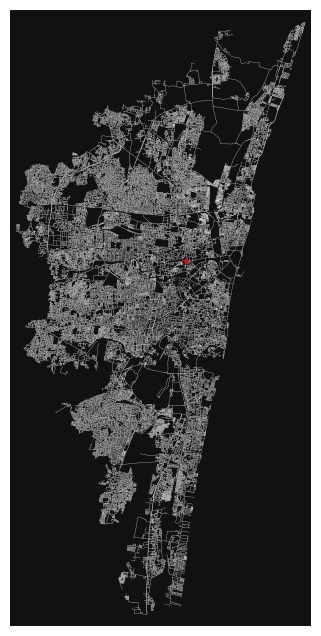

In [36]:
import osmnx as ox
import matplotlib.pyplot as plt

# assume G already exists
node_id = 11187026047

# plot base graph
fig, ax = ox.plot_graph(
    G0,
    node_size=0,
    edge_color="white",
    show=False,
    edge_linewidth=.1,
    close=False
)

# get coordinates of the node
x = G0.nodes[node_id]["x"]
y = G0.nodes[node_id]["y"]

# highlight the node
ax.scatter(
    x, y,
    c="red",
    s=5,
    zorder=5
)

plt.savefig("temp.pdf")


In [ ]:

print("3/3 data saved. plot initiated")
topNPlotMap(city1, X, idx2node)